# 03 Exploratory Analysis

This notebook explores unadjusted associations between demographic, 
lifestyle, body composition, and chronic condition factors and 
functional movement difficulty.

Input: cleaned_data.csv (from notebook 02)

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
# Consistent color palette across all plots
COLOR_NO = '#27ae60'   # no limitation
COLOR_YES = '#c0392b'  # has limitation

# Load cleaned data
df = pd.read_csv('../data/cleaned_data.csv')

print("Sample size:", df.shape[0])
print(df.head())

Sample size: 1347
      SEQN  RIDAGEYR  RIAGENDR  BMXBMI  PAD680  PAQ605  PFQ061D  PFQ061H  \
0  93716.0      61.0       1.0    30.7   300.0     2.0      1.0      1.0   
1  93718.0      45.0       1.0    22.0   240.0     2.0      1.0      1.0   
2  93721.0      60.0       2.0    35.9   120.0     2.0      1.0      1.0   
3  93722.0      60.0       2.0    23.8   240.0     2.0      1.0      1.0   
4  93723.0      64.0       1.0    22.4   120.0     1.0      1.0      1.0   

   PFQ061I  PFQ061M  MCQ160A  arthritis  sitting_hours  PFQ061D_score  \
0      1.0      1.0      1.0          1            5.0              0   
1      1.0      1.0      2.0          0            4.0              0   
2      1.0      1.0      2.0          0            2.0              0   
3      1.0      1.0      2.0          0            4.0              0   
4      1.0      1.0      1.0          1            2.0              0   

   PFQ061H_score  PFQ061I_score  PFQ061M_score  FLI  functional_limitation  \
0       

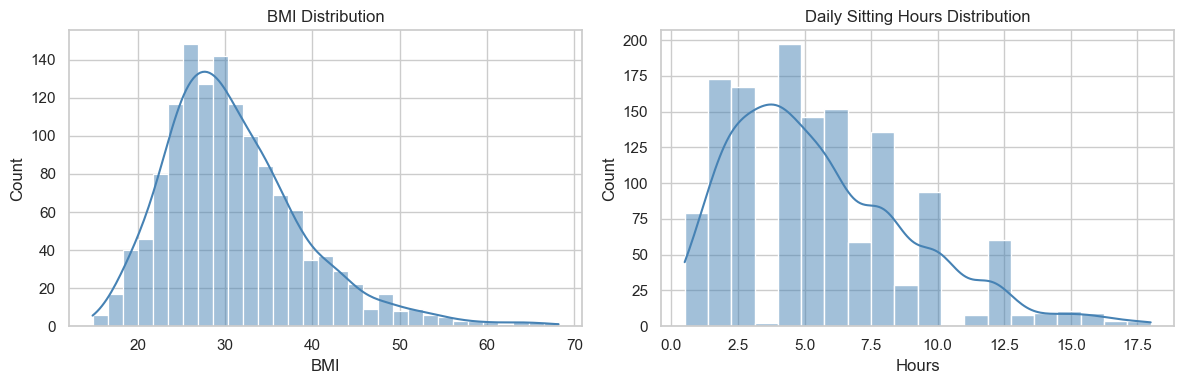

In [33]:
# Distribution of key continuous predictors
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df['BMXBMI'], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('BMI Distribution')
axes[0].set_xlabel('BMI')

sns.histplot(df['sitting_hours'], kde=True, ax=axes[1], color='steelblue')
axes[1].set_title('Daily Sitting Hours Distribution')
axes[1].set_xlabel('Hours')

plt.tight_layout()
plt.savefig('../visualizations/00_variable_distributions.png', dpi=150)
plt.show()

arthritis
0    0.510363
1    0.840000
Name: functional_limitation, dtype: float64


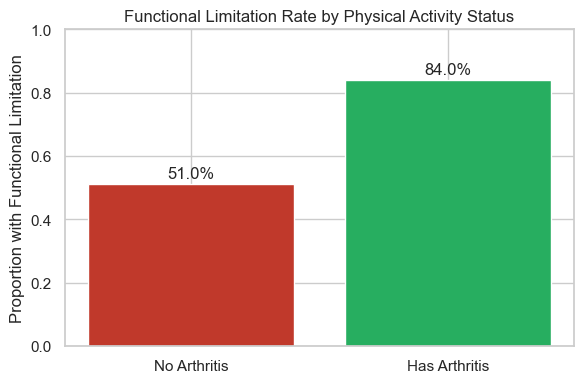

In [34]:
# Unadjusted association between vigorous activity and functional limitation
# Note: no confounders controlled — adjusted analysis in notebook 04

# Functional limitation prevalence by vigorous activity status (unadjusted)
print(df.groupby('arthritis')['functional_limitation'].mean())
grouped = df.groupby('arthritis')['functional_limitation'].mean()
grouped.index = ['No Arthritis', 'Has Arthritis']

plt.figure(figsize=(6, 4))
plt.bar(grouped.index, grouped.values, color=[COLOR_YES, COLOR_NO])
plt.title('Functional Limitation Rate by Physical Activity Status')
plt.ylabel('Proportion with Functional Limitation')
plt.ylim(0, 1)
for i, v in enumerate(grouped.values):
    plt.text(i, v + 0.02, f'{v:.1%}', ha='center')
plt.tight_layout()
plt.savefig('../visualizations/01_limitation_by_activity.png', dpi=150)
plt.show()

Functional limitation prevalence was similar across vigorous activity 
groups in the unadjusted analysis.

                       count      mean       std  min  25%  50%  75%   max
functional_limitation                                                     
0                      470.0  5.091844  3.164134  0.5  3.0  4.0  7.0  16.0
1                      877.0  5.861365  3.512690  0.5  3.0  5.0  8.0  18.0


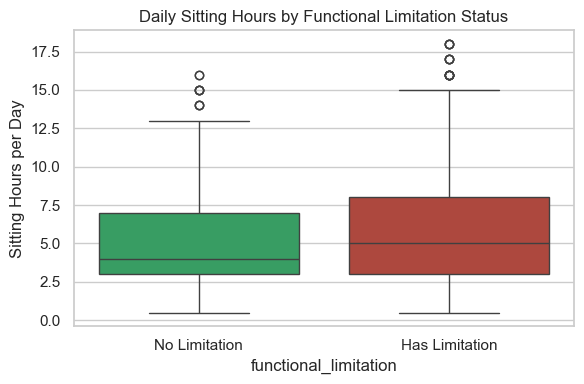

In [35]:
# Sitting hours distribution by functional limitation status (unadjusted)
print(df.groupby('functional_limitation')['sitting_hours'].describe())

plt.figure(figsize=(6, 4))
sns.boxplot(x='functional_limitation', y='sitting_hours', data=df,
            hue='functional_limitation', palette=[COLOR_NO, COLOR_YES], legend=False)
plt.xticks([0, 1], ['No Limitation', 'Has Limitation'])
plt.title('Daily Sitting Hours by Functional Limitation Status')
plt.ylabel('Sitting Hours per Day')
plt.tight_layout()
plt.savefig('../visualizations/02_sitting_by_limitation.png', dpi=150)
plt.show()

Sitting hour distributions were broadly similar between groups 
in the unadjusted analysis.

                       count       mean       std   min   25%   50%     75%  \
functional_limitation                                                         
0                      470.0  28.910638  6.403368  15.7  24.6  28.2  32.275   
1                      877.0  32.184036  8.688706  14.8  26.0  30.8  36.500   

                        max  
functional_limitation        
0                      52.8  
1                      68.2  


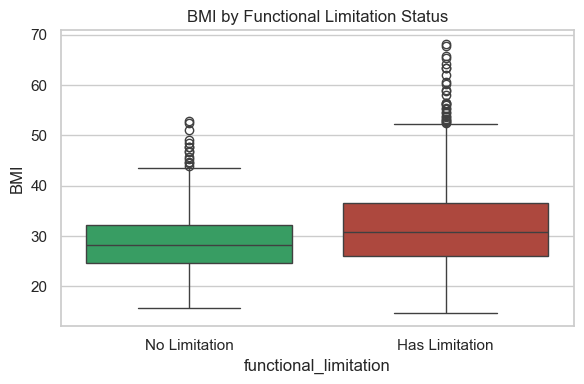

In [36]:
# BMI distribution by functional limitation status (unadjusted)
print(df.groupby('functional_limitation')['BMXBMI'].describe())

plt.figure(figsize=(6, 4))
sns.boxplot(x='functional_limitation', y='BMXBMI', data=df,
            hue='functional_limitation', palette=[COLOR_NO, COLOR_YES], legend=False)
plt.xticks([0, 1], ['No Limitation', 'Has Limitation'])
plt.title('BMI by Functional Limitation Status')
plt.ylabel('BMI')
plt.tight_layout()
plt.savefig('../visualizations/03_bmi_by_limitation.png', dpi=150)
plt.show()

Participants reporting functional limitation showed higher median 
BMI values in the unadjusted analysis.

age_group
20-35    0.500000
36-50    0.815789
51-65    0.641409
Name: functional_limitation, dtype: float64


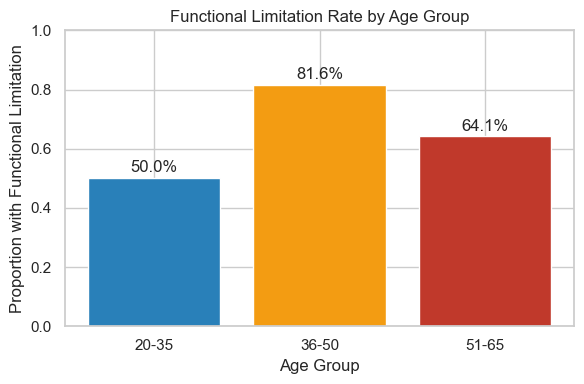

In [37]:
# Functional limitation prevalence by age group (unadjusted)
df['age_group'] = pd.cut(df['RIDAGEYR'], bins=[20, 35, 50, 65],
                          labels=['20-35', '36-50', '51-65'])
print(df.groupby('age_group', observed=True)['functional_limitation'].mean())

age_grouped = df.groupby('age_group', observed=True)['functional_limitation'].mean()

plt.figure(figsize=(6, 4))
plt.bar(age_grouped.index, age_grouped.values, color=['#2980b9', '#f39c12', '#c0392b'])
plt.title('Functional Limitation Rate by Age Group')
plt.ylabel('Proportion with Functional Limitation')
plt.xlabel('Age Group')
plt.ylim(0, 1)
for i, v in enumerate(age_grouped.values):
    plt.text(i, v + 0.02, f'{v:.1%}', ha='center')
plt.tight_layout()
plt.savefig('../visualizations/04_limitation_by_age.png', dpi=150)
plt.show()

The 36–50 age group showed a relatively high prevalence of 
functional limitation in the unadjusted analysis.

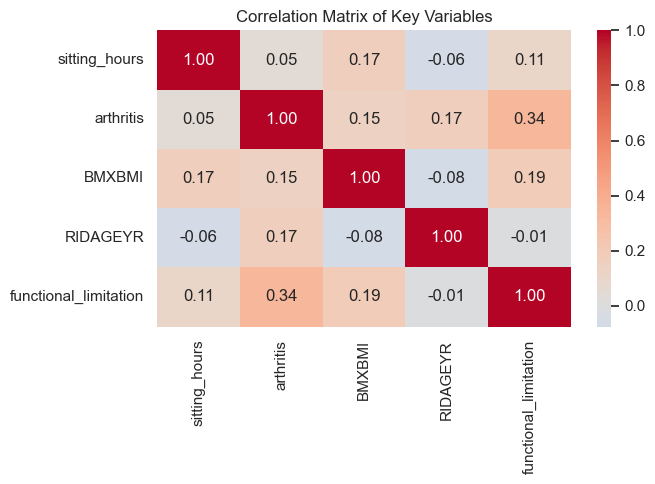

In [38]:
# Correlation matrix among key variables
corr_vars = ['sitting_hours', 'arthritis', 'BMXBMI', 
             'RIDAGEYR', 'functional_limitation']
corr = df[corr_vars].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix of Key Variables')
plt.tight_layout()
plt.savefig('../visualizations/05_correlation_matrix.png', dpi=150)
plt.show()

In [39]:
# Descriptive summary by functional limitation status (Table 1)
table1 = df.groupby('functional_limitation').agg(
    Age=('RIDAGEYR', 'mean'),
    BMI=('BMXBMI', 'mean'),
    Sitting_Hours=('sitting_hours', 'mean'),
    Arthritis=('arthritis', 'mean')
).round(2)
table1.index = ['No Limitation', 'Has Limitation']
print(table1)

                  Age    BMI  Sitting_Hours  Arthritis
No Limitation   53.10  28.91           5.09       0.20
Has Limitation  52.97  32.18           5.86       0.55


BMI and arthritis demonstrated the clearest unadjusted separation between 
groups. Arthritis prevalence was substantially higher in the functional 
limitation group (55% vs 20%), while BMI was also notably elevated. 
Sedentary time showed comparatively modest differences. These findings 
informed variable selection for multivariable modeling.

In [40]:
# Exploratory analysis complete — proceeding to logistic regression in notebook 04
print("Exploratory analysis complete.")
print("Charts saved to visualizations/")

Exploratory analysis complete.
Charts saved to visualizations/
